In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
export_hwannier("wannier", spin=Val('u'))
export_hwannier("wannier", spin=Val('d'))
export_momentum("wannier", spin=Val('u'))
export_momentum("wannier", spin=Val('d'));
export_heph("wannier", spin=Val('u'));
export_heph("wannier", spin=Val('d'));

In [5]:
kpoints = bandstructkpoints2q(kpointsfile="../bandstruct.kpoints", interpolate=5);

In [3]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt")
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");
Pwannier = pwannier("wannierDn");
Heph, celleph_map = hephwannier("wannierDn"), np.loadtxt("wannierDn.mapeph.txt");
lattice_vectors = loadlattice("./wannier.out");

In [26]:
polarizations = []
for (i,k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    push!(polarizations, ImΠ(HwannierDn, cell_mapDn, lattice_vectors, k, -4.74, Val(2), histogram_width=1000, mesh=100, monte_carlo=true))
end

1
[0.0, 0.0, 0.0]
2
[0.0058823529412, 0.0, 0.0]
3
[0.0117647058824, 0.0, 0.0]
4
[0.0176470588236, 0.0, 0.0]
5
[0.0235294117648, 0.0, 0.0]
6
[0.029411764706, 0.0, 0.0]
7
[0.0352941176472, 0.0, 0.0]
8
[0.0411764705884, 0.0, 0.0]
9
[0.0470588235296, 0.0, 0.0]
10
[0.0529411764708, 0.0, 0.0]
11
[0.058823529412, 0.0, 0.0]
12
[0.0647058823532, 0.0, 0.0]
13
[0.0705882352944, 0.0, 0.0]
14
[0.0764705882356, 0.0, 0.0]
15
[0.0823529411768, 0.0, 0.0]
16
[0.088235294118, 0.0, 0.0]
17
[0.0941176470592, 0.0, 0.0]
18
[0.1000000000004, 0.0, 0.0]
19
[0.1058823529416, 0.0, 0.0]
20
[0.1117647058828, 0.0, 0.0]
21
[0.117647058824, 0.0, 0.0]
22
[0.123529411765, 0.0, 0.0]
23
[0.129411764706, 0.0, 0.0]
24
[0.135294117647, 0.0, 0.0]
25
[0.14117647058799998, 0.0, 0.0]
26
[0.147058823529, 0.0, 0.0]
27
[0.1529411764702, 0.0, 0.0]
28
[0.1588235294114, 0.0, 0.0]
29
[0.1647058823526, 0.0, 0.0]
30
[0.1705882352938, 0.0, 0.0]
31
[0.176470588235, 0.0, 0.0]
32
[0.1823529411762, 0.0, 0.0]
33
[0.1882352941174, 0.0, 0.0]
34


In [67]:
energies = range(0, 100, length=100000)
energies = collect(energies)
#epsilons_scipy = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i != 48 && continue
    for (j, ω) in enumerate(range(0.05, 2, length=100))
       epsilons_scipy[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=100), Val(2), Val(:scipy), limit=100, δ=0.001, normalized=true))
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [39]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_default = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    for (j, ω) in enumerate(range(0.05, 2, length=100))
        epsilons_default[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=100), Val(2), Val(:default), limit=20, δ=0.001, normalized=true))
    end
end

In [88]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_quadgk = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    for (j, ω) in enumerate(range(0.05, 2, length=100)[1:100])
    x = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=100), Val(2), Val(:quadgk), rtol=1e-7, atol=1e-7, δ=0.1, normalized=true))
     epsilons_quadgk[i, j] = x
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [89]:
plasmon_quadgk = [range(0.05, 2, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_quadgk[2:50, :])))];
plasmon_quadgk = [0, plasmon_quadgk...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_quadgk);
plasmon_quadgk = smooth(plasmon_quadgk, win_len=10);
plasmon_quadgk[1] = 0;

In [68]:
plasmon_default = [range(0.05, 2, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_default[2:50, :])))];
plasmon_default = [0, plasmon_default...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_default);
plasmon_default = smooth(plasmon_default, win_len=10);
plasmon_default[1] = 0;

In [78]:
plasmon_scipy = [range(0.05, 2, length=100)[argmin(x)] for x in eachrow(smooth(log.(abs.((epsilons_scipy[2:50, :]))), win_len=10))];
plasmon_scipy = [0, plasmon_scipy...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_scipy);
plasmon_scipy = smooth(plasmon_scipy, win_len=10);
plasmon_scipy[1] = 0;

In [4]:
qs, plasmon_default, plasmon_scipy, plasmon_quadgk = [collect(x) for x in eachcol(np.loadtxt("plasmon.txt"))];

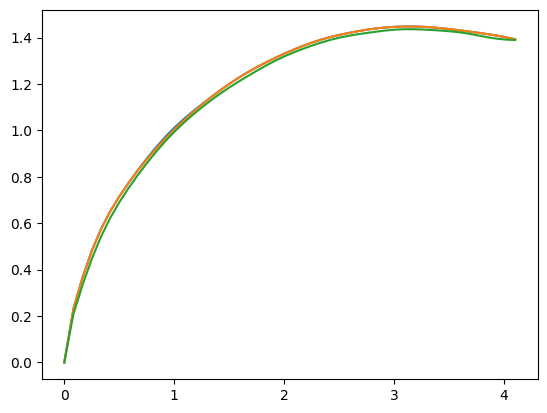

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f3dca3e8910>

In [5]:
plot(qs*10, plasmon_scipy)
plot(qs*10, plasmon_default)
plot(qs*10, plasmon_quadgk)

In [96]:
np.savetxt("plasmon.txt", hcat(qs, plasmon_default, plasmon_scipy, plasmon_quadgk), header="qs, default, scipy, quadgk")

In [5]:
force_matrix, cellph_map = phonon_force_matrix("../phonon");
phonon_bands_bn22nc = phonon_dispersion(force_matrix, cellph_map, kpointsfile="../bandstruct.kpoints", return_negative=true);

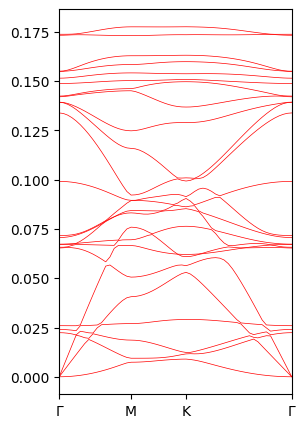

(0.0, 55.0)

In [7]:
figure(figsize=(3, 5))
plot(phonon_bands_bn22nc, linewidth=0.5, color="red")
label_plots()

In [28]:
x, y = density_of_states(HwannierDn, cell_mapDn, mesh=20, num_blocks=1000, monte_carlo=true, histogram_width=10)

([-6.059520605805029, -5.95945891160297, -5.85939721740091, -5.759335523198851, -5.659273828996791, -5.559212134794731, -5.459150440592672, -5.359088746390612, -5.259027052188553, -5.158965357986493  …  -4.258410110167956, -4.1583484159658965, -4.058286721763837, -3.958225027561778, -3.8581633333597183, -3.7581016391576587, -3.6580399449555987, -3.557978250753539, -3.4579165565514796, -3.35785486234942], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.006125  …  0.001775, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

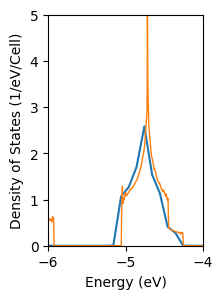

(0.0, 5.0)

In [33]:
figure(figsize=(2, 3))
plot(x, smooth(y, win_len=1))
density_of_states("../DOS/BN22NC.dosDn", linewidth=1)
xlim(-6, -4)
#xlim(-4.8, -4.6)
ylim(0, 5)

In [32]:
e, n = find_chemical_potential(x, y);

In [35]:
# The DOS at the fermi level
μ = e[argmin(abs.(n .- 0.5))]
gμ = y[argmin(abs.(x .- μ))]

println("The chemical potential is: $μ")
println("The DOS at μ is: $gμ")

The chemical potential is: -4.758718581178254
The DOS at μ is: 2.5842750000000003


In [24]:
es, cs = drude_conductivity(lattice_vectors, HwannierDn, cell_mapDn, Pwannier, mesh=20, num_blocks=500, histogram_width=100)

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100
Block: 1

([-100.0, -99.989999499975, -99.97999899995, -99.969998499925, -99.9599979999, -99.949997499875, -99.93999699985, -99.929996499825, -99.9199959998, -99.909995499775  …  99.909995499775, 99.9199959998, 99.929996499825, 99.93999699985, 99.949997499875, 99.9599979999, 99.969998499925, 99.97999899995, 99.989999499975, 100.0], [0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0]

[0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0]

[0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0])

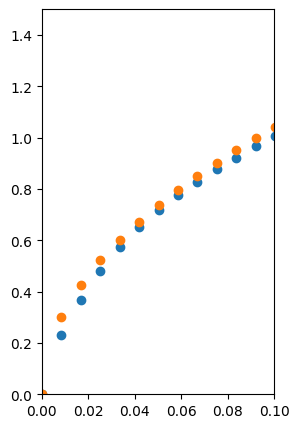

(0.0, 1.5)

In [53]:
figure(figsize=(3, 5))
scatter(qs, plasmon_default)
scatter(qs, sqrt.(e²ϵ/8*0.4766229549069560*qs))
xlim(0, 0.1)
ylim(0,1.5)
#plot(es, (smooth(cs[:, 1, 1]+cs[:, 2, 2], win_len=5))/2)
#xlim(-4.8, -4.7)
#xlim(-5, -4)
#ylim(0.4, 0.5)

In [50]:
(smooth(cs[:, 1, 1], win_len=5)[argmin(abs.(es .+ 4.74))]+smooth(cs[:, 2, 2], win_len=5)[argmin(abs.(es .+ 4.74))])/2

0.47662295490695605

In [51]:
println("The conductivity is $(100*0.4766229549069560/(2/pi))% of graphene at 0.5 eV doping") 

The conductivity is 74.86775868339761% of graphene at 0.5 eV doping


In [5]:
tau_allen_inv = zeros(100)
N = 200
for i in 1:N
    tau_allen_inv += 1 ./ np.loadtxt("tau/tau.out-$i")
end
tau_allen_inv *= 1/N 
tau_allen = 1 ./ tau_allen_inv;

In [6]:
omegas = 0.01:0.01:1;
np.savetxt("tau_allen.txt", hcat(omegas, tau_allen))

In [7]:
omegas, tau_allen = [col for col in eachcol(np.loadtxt("tau_allen.txt"))];

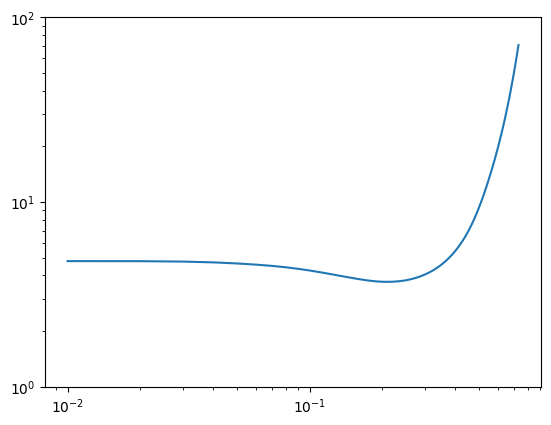

In [8]:
loglog(omegas[1:73], tau_allen[1:73])
ylim(1, 100);